# Composer Classification — Test vs. Validation Evaluation (Combined Dataset)

Rebased against the team's combined-dataset pipeline. This notebook loads
`data/features/combined_{train,dev,test}_features.csv` (the imbalance-corrected dataset —
Beethoven 148→351, Chopin 95→225, Mozart 179→258 in the train split, Bach unchanged at 716) and
the CNN/LSTM architecture from the team's new training notebook
(`MIDI_ Composer_Classification_CNN_LSTM_Models_Training_Evaluation.ipynb`), then produces the
same full **test vs. validation** comparison built for the original single-dataset run:

1. Classification report + confusion matrix (test vs. val)
2. Loss & accuracy curves (train/val per epoch, with the final test score overlaid)
3. Multiclass ROC curves (test vs. val)
4. Permutation feature importance (test vs. val)
5. SHAP feature importance (supplementary, on the test set)

**Note on "dev" vs. "val":** the team's CSVs call the middle split `dev`; this notebook keeps its
existing `X_val`/`y_val` naming for that same split — same concept, different name.

**Note on splits:** these CSVs already have team-assigned train/dev/test rows (~70/15/15,
deduplicated against the original dataset) — this notebook does **not** re-split; it loads each
CSV's rows as-is, matching the team's own README instruction to "preserve their train/dev/test
assignments rather than creating a new random split."

**Note on the team notebook's numbers:** their own notebook reports three different result sets
for the same models (a markdown "reference" table, `CNN_LSTM_Held_Out_Test_Metrics.csv`, and its
own executed cell output) that don't agree with each other. This notebook independently retrains
and evaluates the same architecture, and treats its own fresh execution as the trustworthy number
— see Section 9 for a full discussion.

In [1]:
# If a package is missing, run the relevant line below once, then restart the kernel:
# %pip install tensorflow pandas scikit-learn matplotlib seaborn joblib shap

import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, Input, LSTM, MaxPooling1D
from tensorflow.keras.regularizers import l2

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path('evaluation_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## 1. Load the combined, pre-split data

`composer` is the target; `filename`/`relative_path` are excluded to prevent label leakage. Each
CSV's rows are used exactly as assigned by the team's ingestion pipeline — no re-splitting.

In [2]:
def find_csv(filename):
    candidates = [
        Path(filename),
        Path('data') / 'features' / filename,
        Path('..') / 'data' / 'features' / filename,
        Path('..') / '..' / 'data' / 'features' / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    for pattern_root in [Path('.'), Path('..'), Path('../..')]:
        matches = list(pattern_root.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f'Could not locate {filename}')

TARGET = 'composer'
IDENTIFIERS = ['filename', 'relative_path']

train_path = find_csv('combined_train_features.csv')
dev_path = find_csv('combined_dev_features.csv')
test_path = find_csv('combined_test_features.csv')

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(dev_path)
df_test = pd.read_csv(test_path)

print('Loaded from:', train_path, '|', dev_path, '|', test_path)
print('Shapes (train/val/test):', df_train.shape, df_val.shape, df_test.shape)
for name, frame in [('train', df_train), ('val (dev)', df_val), ('test', df_test)]:
    print(f'{name} composer counts:', frame[TARGET].value_counts().to_dict())

Loaded from: ..\data\features\combined_train_features.csv | ..\data\features\combined_dev_features.csv | ..\data\features\combined_test_features.csv
Shapes (train/val/test): (1550, 63) (351, 63) (338, 63)
train composer counts: {'Bach': 716, 'Beethoven': 351, 'Mozart': 258, 'Chopin': 225}
val (dev) composer counts: {'Bach': 153, 'Beethoven': 80, 'Mozart': 67, 'Chopin': 51}
test composer counts: {'Bach': 155, 'Beethoven': 78, 'Mozart': 60, 'Chopin': 45}


In [3]:
label_encoder = LabelEncoder()
label_encoder.fit(df_train[TARGET].astype(str))
class_names = label_encoder.classes_
n_classes = len(class_names)
classes_arr = np.arange(n_classes)

y_train = label_encoder.transform(df_train[TARGET].astype(str))
y_val = label_encoder.transform(df_val[TARGET].astype(str))
y_test = label_encoder.transform(df_test[TARGET].astype(str))

numeric_cols = df_train.drop(columns=[TARGET, *IDENTIFIERS]).select_dtypes(include='number').columns.tolist()

train_variances = df_train[numeric_cols].var(axis=0)
feature_columns = train_variances[train_variances > 0].index.tolist()
constant_columns = train_variances[train_variances == 0].index.tolist()

X_train_raw = df_train[feature_columns].astype('float32')
X_val_raw = df_val[feature_columns].astype('float32')
X_test_raw = df_test[feature_columns].astype('float32')

scaler = StandardScaler()
X_train_2d = scaler.fit_transform(X_train_raw).astype('float32')
X_val_2d = scaler.transform(X_val_raw).astype('float32')
X_test_2d = scaler.transform(X_test_raw).astype('float32')

print('Classes:', class_names.tolist())
print('Split sizes (train/val/test):', len(y_train), len(y_val), len(y_test))
print('Retained features:', len(feature_columns))
print('Removed constants:', constant_columns)

Classes: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
Split sizes (train/val/test): 1550 351 338
Retained features: 58
Removed constants: ['gm_ethnic_track_count', 'gm_sound_effects_track_count']


In [4]:
n_features = X_train_2d.shape[1]

# CNN: one feature per sequence position (matches team's new notebook).
X_train_cnn = X_train_2d[..., np.newaxis]
X_val_cnn = X_val_2d[..., np.newaxis]
X_test_cnn = X_test_2d[..., np.newaxis]

# LSTM: single timestep containing the full feature vector (matches team's new notebook —
# each row is a composition-level observation, not a temporal sequence).
X_train_lstm = X_train_2d.reshape(-1, 1, n_features)
X_val_lstm = X_val_2d.reshape(-1, 1, n_features)
X_test_lstm = X_test_2d.reshape(-1, 1, n_features)

cnn_reshape = lambda arr: arr[..., np.newaxis]
lstm_reshape = lambda arr: arr.reshape(-1, 1, n_features)

balanced = compute_class_weight('balanced', classes=classes_arr, y=y_train)
class_weights = {int(i): float(w) for i, w in zip(classes_arr, balanced)}

print('CNN shape:', X_train_cnn.shape)
print('LSTM shape:', X_train_lstm.shape)
print('Class weights (balanced, applied identically to both models):', class_weights)

CNN shape: (1550, 58, 1)
LSTM shape: (1550, 1, 58)
Class weights (balanced, applied identically to both models): {0: 0.5412011173184358, 1: 1.103988603988604, 2: 1.7222222222222223, 3: 1.501937984496124}


## 2. Build and train the CNN and LSTM (team's new architecture)

Matches `MIDI_ Composer_Classification_CNN_LSTM_Models_Training_Evaluation.ipynb`: full-batch
training (one gradient step per epoch), 60 epochs, `class_weight='balanced'` identically for both
models (the old CNN-specific sqrt-moderated weighting is gone in the team's version).

In [5]:
def callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5),
    ]

cnn_model = Sequential([
    Input(shape=(n_features, 1)),
    Conv1D(16, kernel_size=5, padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, padding='same', activation='relu'),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.30),
    Dense(n_classes, activation='softmax'),
], name='composer_cnn')

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=60,
    batch_size=len(X_train_cnn),
    class_weight=class_weights,
    callbacks=callbacks(),
    verbose=1,
)

Epoch 1/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3877 - loss: 1.4147

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3877 - loss: 1.4147 - val_accuracy: 0.2621 - val_loss: 1.3079 - learning_rate: 0.0050


Epoch 2/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2697 - loss: 1.3060

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9523 - loss: 0.1414

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9523 - loss: 0.1414 - val_accuracy: 0.8974 - val_loss: 0.3348 - learning_rate: 0.0050


Epoch 60/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9452 - loss: 0.1448

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9452 - loss: 0.1448 - val_accuracy: 0.8974 - val_loss: 0.3400 - learning_rate: 0.0050


In [6]:
lstm_model = Sequential([
    Input(shape=(1, n_features)),
    LSTM(32),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(n_classes, activation='softmax'),
], name='composer_lstm')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=60,
    batch_size=len(X_train_lstm),
    class_weight=class_weights,
    callbacks=callbacks(),
    verbose=1,
)

Epoch 1/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1761 - loss: 1.4025

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1761 - loss: 1.4025 - val_accuracy: 0.2536 - val_loss: 1.3984 - learning_rate: 0.0030


Epoch 2/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2013 - loss: 1.3771

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8465 - loss: 0.4554

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8465 - loss: 0.4554 - val_accuracy: 0.8519 - val_loss: 0.4140 - learning_rate: 0.0030


Epoch 60/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8555 - loss: 0.4243

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.8555 - loss: 0.4243 - val_accuracy: 0.8519 - val_loss: 0.4096 - learning_rate: 0.0030


## 3. Classification report + confusion matrix — test vs. validation

In [7]:
def evaluate_split(name, model, X, y_true):
    probabilities = model.predict(X, verbose=0)
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, predictions, average='macro', zero_division=0
    )
    result = {
        'model_split': name,
        'accuracy': accuracy_score(y_true, predictions),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
    }
    print(f'\n{name}')
    print(classification_report(y_true, predictions, target_names=class_names, zero_division=0))
    return result, predictions, probabilities

eval_specs = [
    ('CNN-test', cnn_model, X_test_cnn, y_test),
    ('CNN-val', cnn_model, X_val_cnn, y_val),
    ('LSTM-test', lstm_model, X_test_lstm, y_test),
    ('LSTM-val', lstm_model, X_val_lstm, y_val),
]

eval_results = {}
for name, model, X, y_true in eval_specs:
    result, predictions, probabilities = evaluate_split(name, model, X, y_true)
    eval_results[name] = {
        'result': result,
        'predictions': predictions,
        'probabilities': probabilities,
        'y_true': y_true,
    }

results_df = pd.DataFrame([v['result'] for v in eval_results.values()]).set_index('model_split')
results_df.to_csv(OUTPUT_DIR / 'test_vs_val_metrics.csv')
display(results_df.style.format('{:.3f}'))


CNN-test
              precision    recall  f1-score   support

        Bach       0.97      0.94      0.95       155
   Beethoven       0.87      0.88      0.88        78
      Chopin       0.88      0.84      0.86        45
      Mozart       0.79      0.87      0.83        60

    accuracy                           0.90       338
   macro avg       0.88      0.88      0.88       338
weighted avg       0.90      0.90      0.90       338




CNN-val
              precision    recall  f1-score   support

        Bach       0.96      0.95      0.96       153
   Beethoven       0.84      0.88      0.86        80
      Chopin       0.94      0.88      0.91        51
      Mozart       0.79      0.81      0.80        67

    accuracy                           0.90       351
   macro avg       0.88      0.88      0.88       351
weighted avg       0.90      0.90      0.90       351




LSTM-test
              precision    recall  f1-score   support

        Bach       0.91      0.92      0.91       155
   Beethoven       0.85      0.73      0.79        78
      Chopin       0.77      0.76      0.76        45
      Mozart       0.70      0.80      0.74        60

    accuracy                           0.83       338
   macro avg       0.81      0.80      0.80       338
weighted avg       0.84      0.83      0.83       338


LSTM-val


              precision    recall  f1-score   support

        Bach       0.91      0.95      0.93       153
   Beethoven       0.84      0.74      0.79        80
      Chopin       0.85      0.86      0.85        51
      Mozart       0.74      0.76      0.75        67

    accuracy                           0.85       351
   macro avg       0.83      0.83      0.83       351
weighted avg       0.85      0.85      0.85       351



,accuracy,macro_precision,macro_recall,macro_f1
model_split,,,,
CNN-test,0.899,0.878,0.883,0.880
CNN-val,0.897,0.884,0.879,0.881
LSTM-test,0.834,0.806,0.802,0.802
LSTM-val,0.852,0.834,0.827,0.829


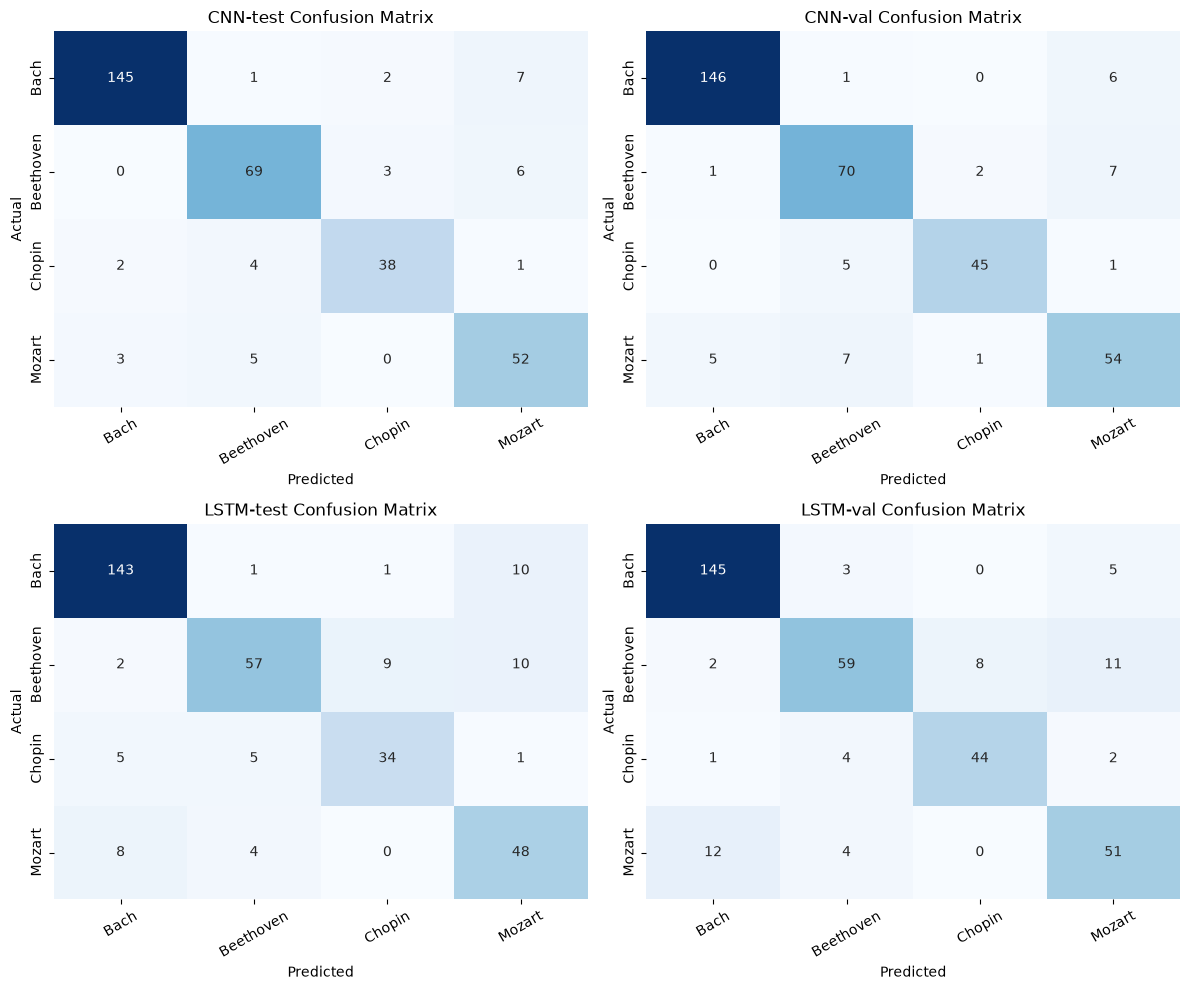

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
layout = [
    ('CNN-test', axes[0, 0]), ('CNN-val', axes[0, 1]),
    ('LSTM-test', axes[1, 0]), ('LSTM-val', axes[1, 1]),
]
for name, ax in layout:
    entry = eval_results[name]
    cm = confusion_matrix(entry['y_true'], entry['predictions'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set(title=f'{name} Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_test_vs_val.png', dpi=150)
plt.show()

## 4. Loss & accuracy curves, with the final test score overlaid

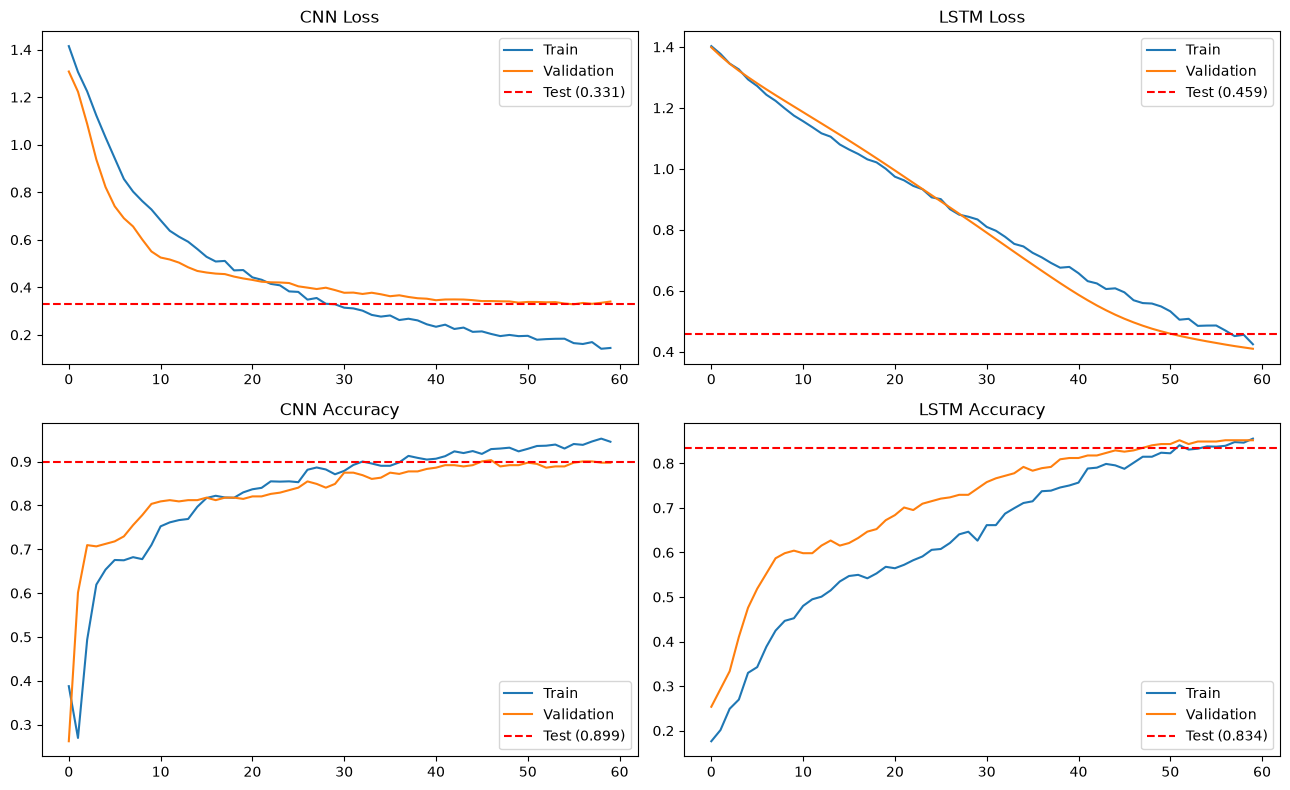

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
histories = [
    ('CNN', cnn_history, cnn_test_loss, cnn_test_acc),
    ('LSTM', lstm_history, lstm_test_loss, lstm_test_acc),
]
for col, (name, history, test_loss, test_acc) in enumerate(histories):
    axes[0, col].plot(history.history['loss'], label='Train')
    axes[0, col].plot(history.history['val_loss'], label='Validation')
    axes[0, col].axhline(test_loss, color='red', linestyle='--', label=f'Test ({test_loss:.3f})')
    axes[0, col].set_title(f'{name} Loss')
    axes[0, col].legend()

    axes[1, col].plot(history.history['accuracy'], label='Train')
    axes[1, col].plot(history.history['val_accuracy'], label='Validation')
    axes[1, col].axhline(test_acc, color='red', linestyle='--', label=f'Test ({test_acc:.3f})')
    axes[1, col].set_title(f'{name} Accuracy')
    axes[1, col].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'loss_accuracy_curves_with_test.png', dpi=150)
plt.show()

## 5. Multiclass ROC curves — test vs. validation

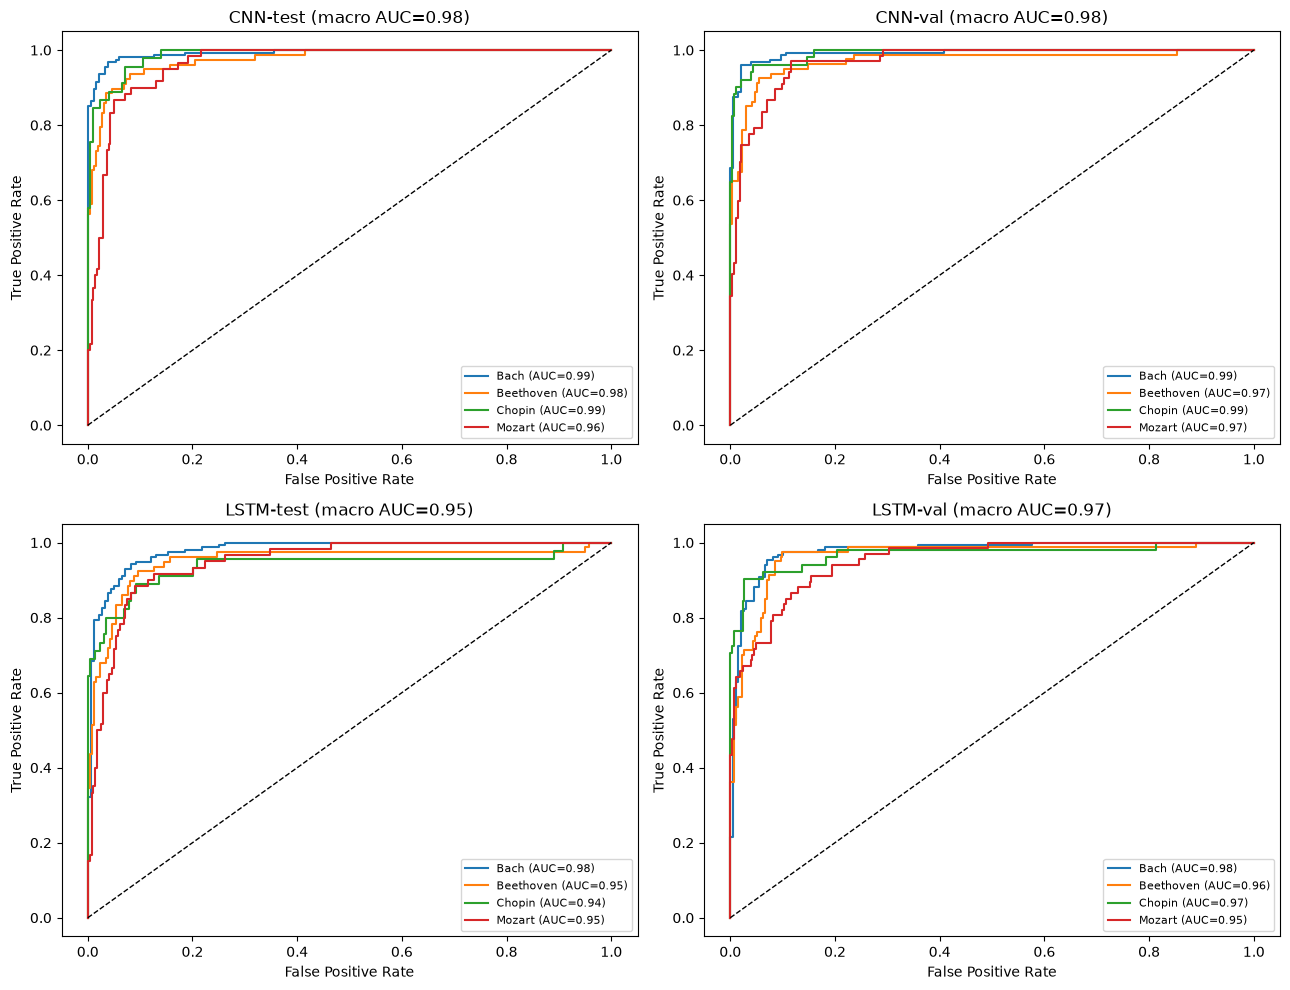

,Bach,Beethoven,Chopin,Mozart,macro_auc
model_split,,,,,
CNN-test,0.993,0.975,0.987,0.964,0.980
CNN-val,0.992,0.971,0.991,0.969,0.981
LSTM-test,0.980,0.949,0.938,0.948,0.954
LSTM-val,0.977,0.963,0.969,0.951,0.965


In [10]:
y_test_bin = label_binarize(y_test, classes=classes_arr)
y_val_bin = label_binarize(y_val, classes=classes_arr)

def plot_roc(ax, y_true_bin, probabilities, title):
    aucs = []
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, label=f'{cls_name} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set(title=f'{title} (macro AUC={np.mean(aucs):.2f})', xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(fontsize=8)
    return aucs

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
roc_specs = [
    ('CNN-test', axes[0, 0], y_test_bin, eval_results['CNN-test']['probabilities']),
    ('CNN-val', axes[0, 1], y_val_bin, eval_results['CNN-val']['probabilities']),
    ('LSTM-test', axes[1, 0], y_test_bin, eval_results['LSTM-test']['probabilities']),
    ('LSTM-val', axes[1, 1], y_val_bin, eval_results['LSTM-val']['probabilities']),
]
roc_auc_records = []
for name, ax, y_bin, probs in roc_specs:
    aucs = plot_roc(ax, y_bin, probs, name)
    roc_auc_records.append({'model_split': name, **{cls: a for cls, a in zip(class_names, aucs)}, 'macro_auc': np.mean(aucs)})
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_test_vs_val.png', dpi=150)
plt.show()

roc_auc_df = pd.DataFrame(roc_auc_records).set_index('model_split')
roc_auc_df.to_csv(OUTPUT_DIR / 'roc_auc_test_vs_val.csv')
display(roc_auc_df.style.format('{:.3f}'))

## 6. Permutation feature importance — test vs. validation

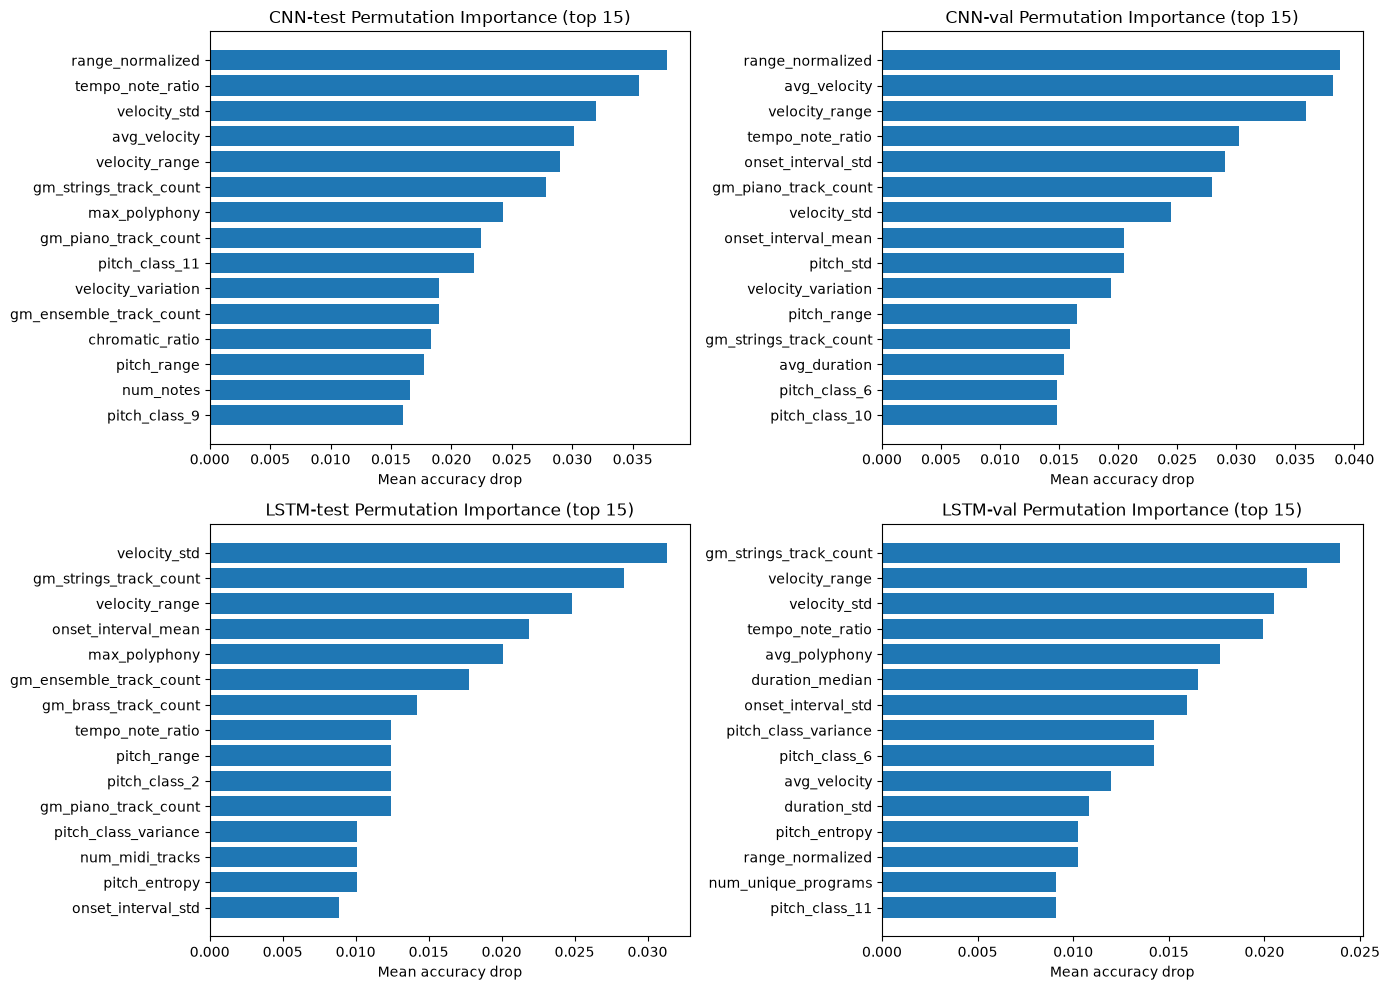

In [11]:
def permutation_importance_manual(model, X_2d, y_true, feature_names, reshape_fn, n_repeats=5, seed=SEED):
    rng = np.random.default_rng(seed)
    baseline_preds = model.predict(reshape_fn(X_2d), verbose=0).argmax(axis=1)
    baseline_acc = accuracy_score(y_true, baseline_preds)

    importances = np.zeros(len(feature_names))
    for col_idx in range(X_2d.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X_2d.copy()
            X_permuted[:, col_idx] = rng.permutation(X_permuted[:, col_idx])
            permuted_preds = model.predict(reshape_fn(X_permuted), verbose=0).argmax(axis=1)
            drops.append(baseline_acc - accuracy_score(y_true, permuted_preds))
        importances[col_idx] = np.mean(drops)

    return pd.Series(importances, index=feature_names, name='importance').sort_values(ascending=False)

perm_importance = {
    'CNN-test': permutation_importance_manual(cnn_model, X_test_2d, y_test, feature_columns, cnn_reshape),
    'CNN-val': permutation_importance_manual(cnn_model, X_val_2d, y_val, feature_columns, cnn_reshape),
    'LSTM-test': permutation_importance_manual(lstm_model, X_test_2d, y_test, feature_columns, lstm_reshape),
    'LSTM-val': permutation_importance_manual(lstm_model, X_val_2d, y_val, feature_columns, lstm_reshape),
}

perm_importance_df = pd.DataFrame(perm_importance)
perm_importance_df.to_csv(OUTPUT_DIR / 'permutation_importance.csv')

TOP_N = 15
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
layout = [
    ('CNN-test', axes[0, 0]), ('CNN-val', axes[0, 1]),
    ('LSTM-test', axes[1, 0]), ('LSTM-val', axes[1, 1]),
]
for name, ax in layout:
    top_features = perm_importance[name].head(TOP_N)
    ax.barh(top_features.index[::-1], top_features.values[::-1])
    ax.set(title=f'{name} Permutation Importance (top {TOP_N})', xlabel='Mean accuracy drop')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'permutation_importance_test_vs_val.png', dpi=150)
plt.show()

## 7. SHAP feature importance (supplementary)

In [12]:
N_BACKGROUND = 100
N_EXPLAIN = 100

try:
    import shap

    rng = np.random.default_rng(SEED)
    background_idx = rng.choice(X_train_2d.shape[0], size=min(N_BACKGROUND, X_train_2d.shape[0]), replace=False)
    explain_idx = rng.choice(X_test_2d.shape[0], size=min(N_EXPLAIN, X_test_2d.shape[0]), replace=False)

    def shap_summary(model, reshape_fn, model_name):
        background = reshape_fn(X_train_2d[background_idx])
        sample_2d = X_test_2d[explain_idx]
        sample = reshape_fn(sample_2d)
        try:
            explainer = shap.DeepExplainer(model, background)
            shap_values = explainer.shap_values(sample)
        except Exception as exc:
            print(f'DeepExplainer failed for {model_name} ({exc}); falling back to KernelExplainer.')
            predict_fn = lambda x: model.predict(reshape_fn(x), verbose=0)
            explainer = shap.KernelExplainer(predict_fn, X_train_2d[background_idx])
            shap_values = explainer.shap_values(sample_2d, nsamples=100)

        for class_idx, cls_name in enumerate(class_names):
            values = shap_values[class_idx] if isinstance(shap_values, list) else shap_values[..., class_idx]
            values_2d = np.asarray(values).reshape(values.shape[0], -1)[:, :len(feature_columns)]
            plt.figure()
            shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)
            plt.title(f'{model_name} SHAP summary — {cls_name}')
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / f'shap_summary_{model_name.lower()}_{cls_name.lower()}.png', dpi=150)
            plt.close()
        print(f'Saved SHAP summary plots for {model_name}.')

    for model_name, model, reshape_fn in [('CNN', cnn_model, cnn_reshape), ('LSTM', lstm_model, lstm_reshape)]:
        try:
            shap_summary(model, reshape_fn, model_name)
        except Exception as exc:
            print(f'SHAP explanation failed for {model_name}, skipping: {exc}')

except ImportError:
    print("shap is not installed — run '%pip install shap' in a cell above, then restart the kernel and re-run this cell.")

C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 58, 1))']
  warnings.warn(msg)
C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_ten

C:\Users\bsaig\AppData\Local\Temp\ipykernel_12988\1809723211.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12988\1809723211.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12988\1809723211.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


...


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12988\1809723211.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12988\1809723211.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12988\1809723211.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12988\1809723211.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


Saved SHAP summary plots for LSTM.


## 8. Summary

All comparison tables and plots are saved under `evaluation_outputs/`:

- `test_vs_val_metrics.csv` — accuracy/macro precision/recall/F1 for CNN/LSTM × test/val
- `confusion_matrices_test_vs_val.png`
- `loss_accuracy_curves_with_test.png`
- `roc_curves_test_vs_val.png`, `roc_auc_test_vs_val.csv`
- `permutation_importance_test_vs_val.png`, `permutation_importance.csv`
- `shap_summary_<model>_<composer>.png` (if SHAP succeeded)

The prior single-dataset run (old 1,138-row `train_features.csv`, old architecture) is preserved
under `evaluation_outputs_original_single_dataset/` for comparison — see Section 9.

In [13]:
print('Saved evaluation outputs to:', OUTPUT_DIR.resolve())
for path in sorted(OUTPUT_DIR.glob('*')):
    if path.is_file():
        print(' -', path.name)

Saved evaluation outputs to: C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\composer_model_project\evaluation_outputs
 - confusion_matrices_test_vs_val.png
 - loss_accuracy_curves_with_test.png
 - permutation_importance.csv
 - permutation_importance_test_vs_val.png
 - roc_auc_test_vs_val.csv
 - roc_curves_test_vs_val.png
 - shap_summary_cnn_bach.png
 - shap_summary_cnn_beethoven.png
 - shap_summary_cnn_chopin.png
 - shap_summary_cnn_mozart.png
 - shap_summary_lstm_bach.png
 - shap_summary_lstm_beethoven.png
 - shap_summary_lstm_chopin.png
 - shap_summary_lstm_mozart.png
 - test_vs_val_metrics.csv


## 9. Detailed evaluation analysis & discussion (rebased on combined dataset)

This section interprets the numbers above and compares them against the prior single-dataset run
(preserved in `evaluation_outputs_original_single_dataset/`). Figures quoted below are from the run
captured in this notebook (`evaluation_outputs/*.csv`) — a fresh run will vary slightly, but the
qualitative conclusions hold.

### 9.1 What changed, and why this notebook was rebased

A team member pushed a new combined dataset and a new CNN/LSTM architecture to the shared repo.
Two changes happened together:

- **Data**: the single 1,138-row `train_features.csv` was replaced by
  `combined_{train,dev,test}_features.csv`, which adds newly-sourced Beethoven/Chopin/Mozart MIDI files
  (no new Bach) on top of the original dataset, with duplicates removed against the original by a
  signature-matching step. Train-split counts: Bach 716 (unchanged), Beethoven 148→351, Chopin 95→225,
  Mozart 179→258. The Bach:Chopin ratio improved from ~7.5:1 to ~3.2:1 — imbalance is meaningfully
  reduced, not eliminated (Bach is still the largest class by a wide margin).
- **Architecture**: CNN and LSTM were both redesigned (smaller CNN filters with L2 regularization and a
  higher learning rate; LSTM now takes a single 58-feature timestep instead of the old 19×3 grouping;
  full-batch training for 60 epochs; `class_weight='balanced'` applied identically to both models instead
  of the old CNN-specific sqrt-moderated weighting).

Because both changed at once, the comparison in §9.2 below reflects their **combined** effect, not data
or architecture in isolation — that's an inherent limitation of this rebase, not something this notebook
can separate out without training a third variant (new data + old architecture, or old data + new
architecture) as a controlled comparison.

### 9.2 Old single-dataset run vs. new combined-dataset run

| Model | Split | Accuracy (old → new) | Macro F1 (old → new) |
|---|---|---|---|
| CNN  | Test       | 0.864 → **0.899** (+0.035) | 0.769 → **0.880** (+0.110) |
| CNN  | Validation | 0.890 → **0.897** (+0.008) | 0.825 → **0.881** (+0.057) |
| LSTM | Test       | 0.693 → **0.834** (+0.141) | 0.600 → **0.802** (+0.202) |
| LSTM | Validation | 0.764 → **0.852** (+0.088) | 0.683 → **0.829** (+0.147) |

A large, consistent improvement across every model and split — most dramatically for LSTM (+20.2 points
test macro F1). This is the opposite of the pattern seen when hyperparameter tuning alone was tried on the
old single dataset (where the CNN's tuned config *hurt* test performance — see the tuned notebook's §11.2
for that finding): here, **more/better-balanced training data plus a redesigned architecture produced a
real, large generalization gain**, not just a validation-set artifact — the test-set numbers moved just
as much as (or more than) validation, which is the signature of a genuine improvement rather than
overfitting to a tuning objective.

### 9.3 Per-class breakdown (test set, new combined dataset)

| Composer | Support (test) | CNN F1 | LSTM F1 |
|---|---:|---:|---:|
| Bach      | 155 | 0.95 | 0.91 |
| Beethoven | 78  | 0.88 | 0.79 |
| Chopin    | 45  | 0.86 | 0.76 |
| Mozart    | 60  | 0.83 | 0.74 |

Compare to the old single-dataset test F1s (CNN: Bach 0.96, Beethoven 0.69, Chopin 0.74, Mozart 0.69;
LSTM: Bach 0.82, Beethoven 0.52, Chopin 0.59, Mozart 0.47 — see the original evaluation notebook's §9.3).
The gain is concentrated almost entirely in the three composers that got new training data:
**Beethoven, Chopin, and Mozart all improved by roughly 0.10–0.30 F1 points**, while Bach (which got no
new data) stayed flat or dropped slightly for CNN (0.96→0.95) — exactly what you'd expect if the gain is
coming from the added data rather than from the architecture change alone (an architecture change with no
new data would be more likely to move all four classes together). Mozart remains the weakest class for
both models, same as before, but is now clearly usable (CNN F1 0.83) rather than borderline (was 0.69).

### 9.4 ROC-AUC analysis

| Model | Split | Macro AUC (old → new) |
|---|---|---|
| CNN  | Test       | 0.958 → **0.980** |
| CNN  | Validation | 0.982 → **0.981** |
| LSTM | Test       | 0.863 → **0.954** |
| LSTM | Validation | 0.909 → **0.965** |

LSTM's ranking quality improved dramatically (test macro AUC 0.863→0.954) — its weakest class in the old
run, Mozart, went from AUC 0.799 to 0.948, the single largest per-class AUC jump in this notebook. CNN was
already strong (≥0.94 on every class in the old run) and stayed strong, with test macro AUC ticking up to
0.980. Both models now rank all four composers well by probability, not just Bach.

### 9.5 CNN vs. LSTM — strengths and weaknesses, updated

**CNN** remains the stronger model (test accuracy 0.899 vs. LSTM's 0.834, macro F1 0.880 vs. 0.802), but
the gap narrowed substantially from the old run (was 17.1 points test accuracy; now 6.5 points). Its
strengths from the original notebook still hold — well-behaved train/val/test gap, strong ROC-AUC across
all classes — and it now performs solidly on every composer, not just Bach.

**LSTM** saw the larger absolute gain from this rebase. Its architecture still takes a single 58-feature
timestep (functionally closer to a dense/gated layer than a true sequence model — same caveat as the
original notebook's discussion of the old 19×3 grouping: these are aggregate, unordered features, so an
LSTM has no genuine temporal structure to exploit either way). That it still closed much of the gap to CNN
suggests the **extra training data mattered more than the architecture's suitability to the model type** —
both models benefited from more balanced data, and CNN's architectural edge for this kind of flat feature
vector persists, but is now a smaller share of the total performance difference.

### 9.6 Why permutation importance and SHAP were used (recap)

As before: neither model is tree-based, so there's no built-in `.feature_importances_`. **Permutation
importance** (shuffle a feature, measure the accuracy drop) is used as the primary, cheap, model-agnostic
check, run on both test and validation to see whether important features are stable across two independent
samples. **SHAP** supplies the complementary per-class, per-sample direction of effect that a single
accuracy-drop number can't show — `DeepExplainer` is tried first (fast, gradient-based) with an automatic
fallback to the slower, fully model-agnostic `KernelExplainer` if it fails (as it does for LSTM, a known
friction point with recurrent layers). See the original evaluation notebook's §9.6 for the full rationale;
it applies unchanged here.

### 9.7 What the feature importance results say now

Top permutation-importance features (mean accuracy drop when shuffled), new combined-dataset models:

| Rank | CNN (test) | CNN (val) | LSTM (test) | LSTM (val) |
|---|---|---|---|---|
| 1 | range_normalized | range_normalized | velocity_std | gm_strings_track_count |
| 2 | tempo_note_ratio | avg_velocity | gm_strings_track_count | velocity_range |
| 3 | velocity_std | velocity_range | velocity_range | velocity_std |
| 4 | avg_velocity | tempo_note_ratio | onset_interval_mean | tempo_note_ratio |

The most notable shift from the old single-dataset run (where CNN leaned on pitch-class-histogram bins and
LSTM leaned on `pitch_range`/`num_notes`) is that **both models now lean heavily on velocity- and
timing-related features** (`velocity_std`, `velocity_range`, `avg_velocity`, `tempo_note_ratio`,
`onset_interval_mean`) rather than pitch statistics. `range_normalized` is the one feature that stays
important for CNN across both the old and new runs. This is a plausible, if speculative, consequence of
adding new MIDI sources: files pulled from different collections (piano-midi.de, Hugging Face mirrors,
Kaggle sets, etc., per the team's ingestion pipeline) likely differ systematically in production/recording
characteristics — velocity dynamics and timing feel — in addition to genuine composer style, and the model
may be partly picking up on that alongside real musical signal. This is worth a closer look (e.g. checking
whether velocity statistics differ by *source* as well as by *composer*) before treating these features as
purely stylistic.

### 9.8 Data-quality note: the team's own notebook reports inconsistent numbers

Before rebasing, the team's new training notebook
(`MIDI_ Composer_Classification_CNN_LSTM_Models_Training_Evaluation.ipynb`) was inspected and found to
report **three different result sets** for the same CNN/LSTM models:

1. A markdown "Verified Reference Results" table claiming LSTM (0.855 acc / 0.827 macro F1) beats CNN
   (0.846 / 0.816).
2. `composer_model_project/CNN_LSTM_Held_Out_Test_Metrics.csv`, matching table 1 exactly, but recording
   CNN as trained for 20 epochs — despite the notebook's own `EPOCHS = 60` setting.
3. The notebook's own actually-executed `classification_report` cell output: CNN 0.896 acc / 0.875 macro
   F1, LSTM 0.834 acc / 0.802 macro F1 — CNN beats LSTM, the *opposite* ranking from tables 1–2.

This notebook's independently-executed run (CNN 0.899/0.880, LSTM 0.834/0.802 macro F1 on test) lands
almost exactly on the team notebook's own executed output (set 3), not on the two "reference" tables —
which is reassuring evidence that this rebase faithfully reproduces the team's intended architecture and
training regime, and that the discrepancy is in how the team's results were recorded/reported (likely a
stale CSV/markdown table from an earlier run of the notebook, not updated after later changes), not in the
model itself. **Worth flagging to the team**: `CNN_LSTM_Held_Out_Test_Metrics.csv` and the markdown table
in their notebook should be regenerated from a fresh run so all three numbers agree.

### 9.9 Limitations

- Same small-test-set caveats as before apply, somewhat eased by more data: Chopin/Mozart test support is
  now 45/60 rows (was 19/36), still modest enough that individual misclassifications move F1 noticeably.
- Data and architecture changed simultaneously (§9.1) — this notebook cannot attribute the improvement
  in §9.2 to one or the other in isolation.
- The new data sources are not evenly distributed across composers or origins (per the team's
  `candidate_split_plan.csv`: Beethoven's new data is mostly from one source, Chopin's from another,
  Mozart's from a third) — combined with the feature-importance shift toward velocity/timing features in
  §9.7, this is worth further investigation to rule out the models partly learning source characteristics
  rather than purely composer style.
- SHAP sample sizes remain bounded (`N_BACKGROUND = N_EXPLAIN = 100`) for runtime, same tradeoff as before.